In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
print('Libraries imported ✔️')

Libraries imported ✔️


In [4]:
file_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/lending_club_rejected_loans.csv'

In [5]:
dtype_dict = {
    'Amount Requested': 'float64',          # numeric loan amount requested
    'Application Date': 'object',           # date string (parse later with pd.to_datetime)
    'Loan Title': 'object',                 # categorical / text
    'Risk_Score': 'float64',                # numeric credit/risk score (may contain NaNs or special values)
    'Debt-To-Income Ratio': 'object',       # string like "15.5%" or "NA" – clean later
    'Zip Code': 'object',                   # string (e.g., "123xx")
    'State': 'object',                      # categorical (2-letter state code)
    'Employment Length': 'object',          # string (e.g., "10+ years", "< 1 year", "n/a")
    'Policy Code': 'float64'                  # categorical / integer code (usually 0 or 1)
}

In [6]:
usecols = list(dtype_dict.keys())
print('Ready to load data...')

Ready to load data...


In [7]:
df_sample = pd.read_csv(
    file_path,
    usecols=usecols,
    dtype=dtype_dict,
    low_memory=False,
    skiprows=lambda i: i > 0 and np.random.rand() > 0.05
)
print('Sample dataset completed')

Sample dataset completed


In [8]:
df_sample.head()

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,10000.0,2007-05-27,NOTIFYi Inc,693.0,10%,210xx,MD,< 1 year,0.0
1,1000.0,2007-05-30,ashtru,695.0,0%,443xx,OH,< 1 year,0.0
2,1100.0,2007-06-04,MATTHEW,551.0,0.72%,334xx,FL,4 years,0.0
3,1000.0,2007-06-14,jessicavk,736.0,25.64%,462xx,IN,2 years,0.0
4,15000.0,2007-06-17,jfernando1,652.0,28.33%,328xx,FL,3 years,0.0


In [9]:
print(df_sample.shape)

(1383082, 9)


In [10]:
missing = df_sample.isnull().sum().sort_values(ascending=False)
print('Top missing columns:\n', missing.head(15))

Top missing columns:
 Risk_Score              925871
Employment Length        47671
Loan Title                  56
Policy Code                 40
Zip Code                    16
State                        1
Amount Requested             0
Debt-To-Income Ratio         0
Application Date             0
dtype: int64


In [11]:
df_clean = df_sample.dropna(subset=['Risk_Score', 'Policy Code', 'Employment Length','Loan Title', 'Zip Code', 'State']).copy()

print(f"Original rows: {len(df_sample):,}")
print(f"Rows after dropping missing key vars: {len(df_clean):,}")
print(f"Rows lost: {len(df_sample) - len(df_clean):,} ({(len(df_sample)-len(df_clean))/len(df_sample)*100:.2f}%)")




Original rows: 1,383,082
Rows after dropping missing key vars: 449,347
Rows lost: 933,735 (67.51%)


In [12]:
df_clean['Application Date'] = pd.to_datetime(df_clean['Application Date'], errors='coerce')

In [13]:
df_clean['Debt-To-Income Ratio'] = (
    df_clean['Debt-To-Income Ratio']
    .str.rstrip('%')
    .replace('NA', np.nan)
    .astype(float) / 100
)

In [14]:
df_clean['Employment Length'] = pd.to_numeric(
    df_clean['Employment Length'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [15]:
print(df_clean.info())
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 449347 entries, 0 to 1383081
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Amount Requested      449347 non-null  float64       
 1   Application Date      449347 non-null  datetime64[ns]
 2   Loan Title            449347 non-null  object        
 3   Risk_Score            449347 non-null  float64       
 4   Debt-To-Income Ratio  449347 non-null  float64       
 5   Zip Code              449347 non-null  object        
 6   State                 449347 non-null  object        
 7   Employment Length     449347 non-null  int64         
 8   Policy Code           449347 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 34.3+ MB
None
Amount Requested        0
Application Date        0
Loan Title              0
Risk_Score              0
Debt-To-Income Ratio    0
Zip Code                0
St

In [16]:
# Normalize Loan Title
df_clean['Loan_Purpose'] = df_clean['Loan Title'].str.lower().str.strip()

# Simple mapping for common purposes (expand as needed)
purpose_map = {
    'debt consolidation': 'Debt Consolidation',
    'debt_consolidation': 'Debt Consolidation',
    'credit card refinancing': 'Credit Card',
    'credit_card': 'Credit Card',
    'home improvement': 'Home Improvement',
    'home_improvement': 'Home Improvement',
    'other': 'Other',
    'car financing': 'Car Financing',
    'medical expenses': 'Medical'
}
df_clean['Loan_Purpose'] = df_clean['Loan_Purpose'].replace(purpose_map).fillna('Other')

# Policy Code as category and flag
df_clean['Policy_Code_Group'] = df_clean['Policy Code'].map({0.0: 'Standard Decline', 2.0: 'Policy 2 (Special)'})
df_clean['Policy_Code_Group'] = df_clean['Policy_Code_Group'].fillna('Standard Decline')

print("Normalized Loan Purpose top 10:\n", df_clean['Loan_Purpose'].value_counts().head(10))
print("\nPolicy Code Group:\n", df_clean['Policy_Code_Group'].value_counts())

Normalized Loan Purpose top 10:
 Loan_Purpose
Debt Consolidation    207656
Other                  68808
Credit Card            56482
Home Improvement       20380
Car Financing          14992
car                     8053
Medical                 7973
small_business          6535
major_purchase          6437
major purchase          6401
Name: count, dtype: int64

Policy Code Group:
 Policy_Code_Group
Standard Decline      448620
Policy 2 (Special)       727
Name: count, dtype: int64


In [17]:
df_clean['Year'] = df_clean['Application Date'].dt.year
df_clean['Quarter'] = df_clean['Application Date'].dt.quarter

In [18]:
df_clean.describe()

,Amount Requested,Application Date,Risk_Score,Debt-To-Income Ratio,Employment Length,Policy Code,Year,Quarter
count,449347.000000,449347,449347.000000,449347.000000,449347.000000,449347.000000,449347.000000,449347.000000
mean,12628.662609,2016-01-19 06:04:11.164467456,627.453409,1.554144,1.436315,0.003236,2015.496193,2.731021
min,500.000000,2007-05-27 00:00:00,0.000000,-0.010000,1.000000,0.000000,2007.000000,1.000000
25%,4000.000000,2014-07-17 00:00:00,591.000000,0.090600,1.000000,0.000000,2014.000000,2.000000
50%,10000.000000,2016-12-14 00:00:00,636.000000,0.205800,1.000000,0.000000,2016.000000,3.000000
75%,20000.000000,2017-10-05 00:00:00,674.000000,0.362100,1.000000,0.000000,2017.000000,4.000000
max,67575.000000,2018-12-31 00:00:00,990.000000,11352.000000,10.000000,2.000000,2018.000000,4.000000
std,10842.901602,NaN,89.651413,46.017093,1.658465,0.080381,2.010093,1.177341


In [19]:
df_clean.shape


(449347, 13)

In [20]:
drive_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/rejected_cleaned_sample.csv'
df_clean.to_csv(drive_path, index=False)
print(f"Saved to Google Drive: {drive_path}")

Saved to Google Drive: /content/drive/MyDrive/CIS450_LendingClub_Project/rejected_cleaned_sample.csv


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [23]:
print("\n=== Numeric Summary ===")
print(df_clean[['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio',
          'Employment Length']].describe())

print("\n=== Categorical Summary ===")
print("Policy Code value counts:\n", df_clean['Policy Code'].value_counts())
print("\nTop 10 Loan Titles:\n", df_clean['Loan Title'].value_counts().head(10))
print("\nTop 10 States:\n", df_clean['State'].value_counts().head(10))


=== Numeric Summary ===
       Amount Requested     Risk_Score  Debt-To-Income Ratio  \
count     449347.000000  449347.000000         449347.000000   
mean       12628.662609     627.453409              1.554144   
std        10842.901602      89.651413             46.017093   
min          500.000000       0.000000             -0.010000   
25%         4000.000000     591.000000              0.090600   
50%        10000.000000     636.000000              0.205800   
75%        20000.000000     674.000000              0.362100   
max        67575.000000     990.000000          11352.000000   

       Employment Length  
count      449347.000000  
mean            1.436315  
std             1.658465  
min             1.000000  
25%             1.000000  
50%             1.000000  
75%             1.000000  
max            10.000000  

=== Categorical Summary ===
Policy Code value counts:
 Policy Code
0.0    448620
2.0       727
Name: count, dtype: int64

Top 10 Loan Titles:
 Loan Title


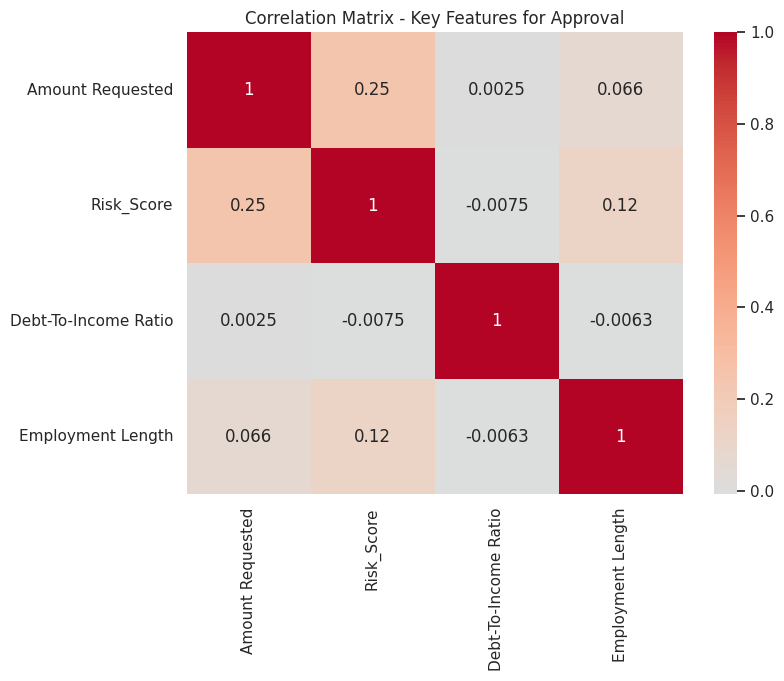

In [24]:
# Most Important Characteristics for Approval/Decline
numeric_cols = ['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio', 'Employment Length']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Features for Approval')
plt.show()

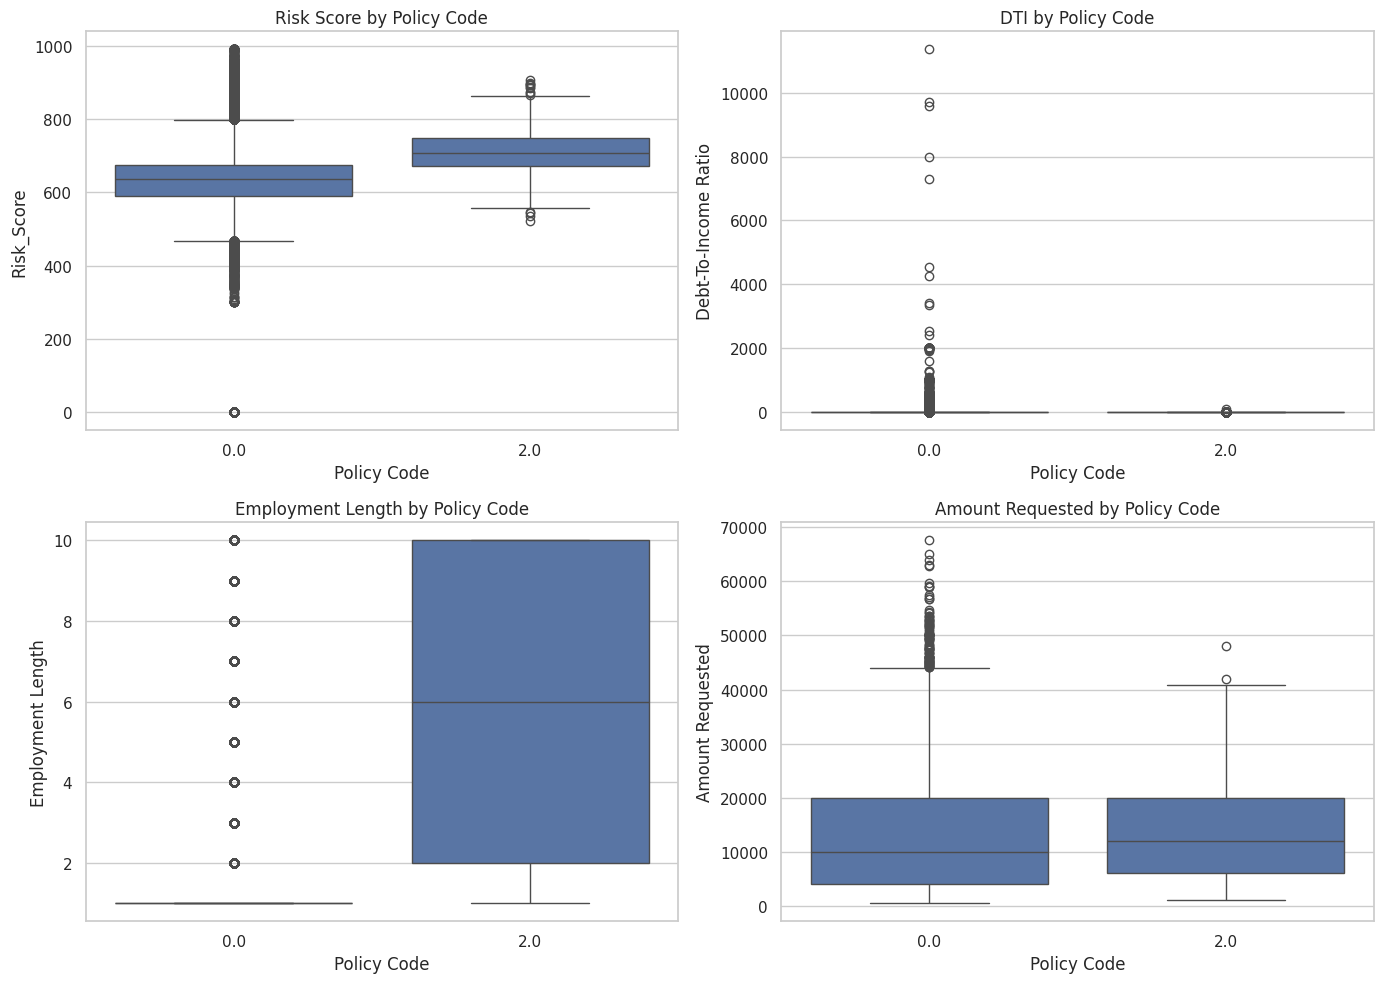

In [25]:
# How features differ by Policy Code
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='Policy Code', y='Risk_Score', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Risk Score by Policy Code')

sns.boxplot(x='Policy Code', y='Debt-To-Income Ratio', data=df_clean, ax=axes[0,1])
axes[0,1].set_title('DTI by Policy Code')

sns.boxplot(x='Policy Code', y='Employment Length', data=df_clean, ax=axes[1,0])
axes[1,0].set_title('Employment Length by Policy Code')

sns.boxplot(x='Policy Code', y='Amount Requested', data=df_clean, ax=axes[1,1])
axes[1,1].set_title('Amount Requested by Policy Code')
plt.tight_layout()
plt.show()

In [26]:
# Factors for Loan Succes / Default Likelihoood
print("\n=== Q2: Factors Most Important for Success vs Default ===")

df_clean['Risk_Score_Bin'] = pd.cut(df_clean['Risk_Score'], bins=[0, 600, 700, 800, 850],
                              labels=['<600', '600-700', '700-800', '>800'])

success_factors = df_clean.groupby('Risk_Score_Bin')[['Debt-To-Income Ratio', 'Employment Length']].mean()
print(success_factors)



=== Q2: Factors Most Important for Success vs Default ===
                Debt-To-Income Ratio  Employment Length
Risk_Score_Bin                                         
<600                        1.556536           1.160990
600-700                     1.247163           1.449819
700-800                     2.235599           1.961707
>800                        5.989372           2.326855


/tmp/ipykernel_4022/1704951798.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_factors = df_clean.groupby('Risk_Score_Bin')[['Debt-To-Income Ratio', 'Employment Length']].mean()


In [27]:
# Missed Good Loans (Declined but likely to Suceed)
print("\n=== Q3: Potential Missed Good Loans ===")
good_profile = (
    (df_clean['Risk_Score'] >= 700) &
    (df_clean['Debt-To-Income Ratio'] <= 0.20) &
    (df_clean['Employment Length'] >= 5) &
    (df_clean['Amount Requested'] <= 20000)
)

missed_loans = df_clean[good_profile & (df_clean['Policy Code'] == 0)]   # Policy Code 0 = declined

print(f"Number of potential 'Missed Good Loans': {len(missed_loans):,}")
print("\nSummary of Missed Good Loans:")
print(missed_loans[['Risk_Score', 'Debt-To-Income Ratio', 'Employment Length',
                    'Amount Requested', 'State']].describe())


=== Q3: Potential Missed Good Loans ===
Number of potential 'Missed Good Loans': 3,322

Summary of Missed Good Loans:
        Risk_Score  Debt-To-Income Ratio  Employment Length  Amount Requested
count  3322.000000           3322.000000        3322.000000       3322.000000
mean    742.651114              0.087150           7.555689      10140.255870
std      44.670471              0.060962           2.259458       5796.227169
min     700.000000             -0.010000           5.000000        500.000000
25%     712.000000              0.030000           5.000000       5000.000000
50%     729.000000              0.086700           8.000000      10000.000000
75%     758.000000              0.138500          10.000000      15000.000000
max     990.000000              0.200000          10.000000      20000.000000


In [28]:
print("\nSample of 10 Missed Good Loans:")
print(missed_loans[['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio',
                    'Employment Length', 'State', 'Loan Title']].head(10))


Sample of 10 Missed Good Loans:
     Amount Requested  Risk_Score  Debt-To-Income Ratio  Employment Length  \
44            14000.0       746.0                0.1020                 10   
102           12000.0       720.0                0.0603                  5   
270            4000.0       700.0                0.1684                  8   
274            7200.0       792.0                0.0067                  6   
326            2500.0       703.0                0.1061                 10   
358            6000.0       700.0                0.1033                  8   
387           20000.0       807.0                0.0029                  6   
435           20000.0       758.0                0.1177                  8   
456           15000.0       782.0                0.0098                 10   
612             500.0       707.0                0.1920                 10   

    State                        Loan Title  
44     OH                     Consolidate22  
102    WA       

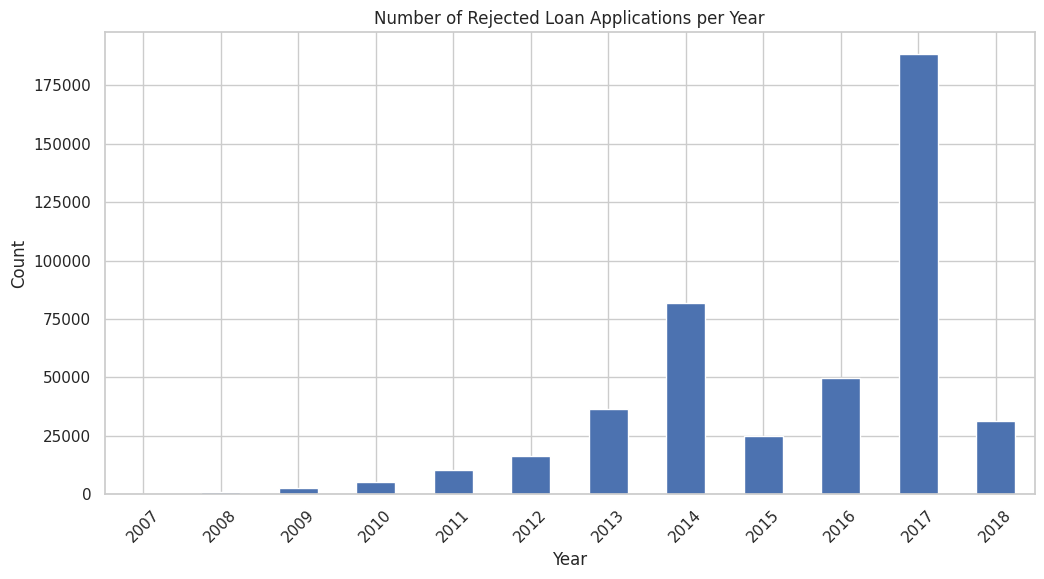

In [29]:
# Trenprint("\n=== Q4: Trends Over Time (2007–2020) ===")

df_clean['Year'] = pd.to_datetime(df_clean['Application Date']).dt.year

annual_rejects = df_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
annual_rejects.plot(kind='bar')
plt.title('Number of Rejected Loan Applications per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

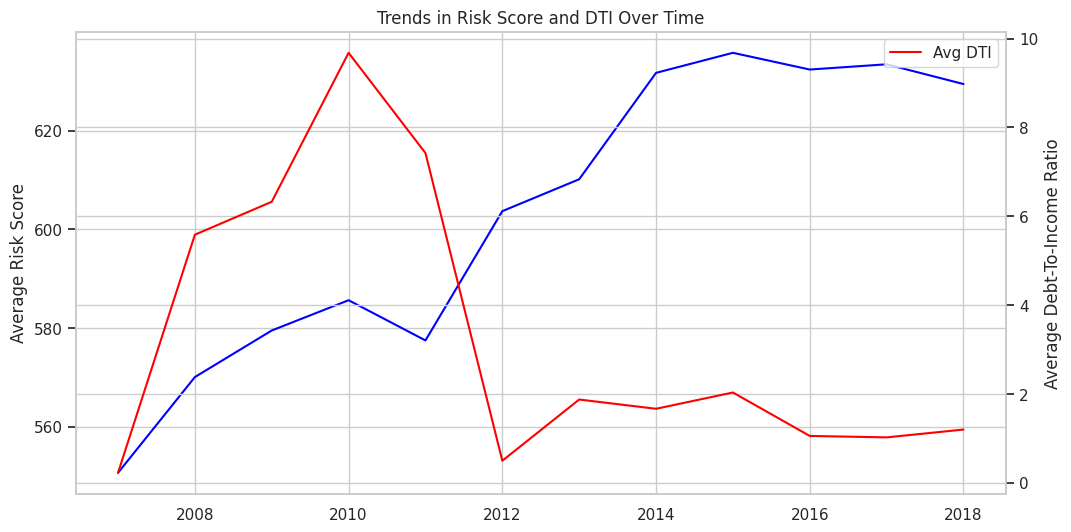

In [30]:
# Average Risk Score & DTI over time

trend = df_clean.groupby('Year')[['Risk_Score', 'Debt-To-Income Ratio']].mean()

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(trend.index, trend['Risk_Score'], color='blue', label='Avg Risk Score')
ax1.set_ylabel('Average Risk Score')
ax2 = ax1.twinx()
ax2.plot(trend.index, trend['Debt-To-Income Ratio'], color='red', label='Avg DTI')
ax2.set_ylabel('Average Debt-To-Income Ratio')
plt.title('Trends in Risk Score and DTI Over Time')
plt.legend()
plt.show()

In [31]:
# Top Loan Titiles among missed good loans
print("\nTop Loan Purposes in Missed Good Loans:")
print(missed_loans['Loan Title'].value_counts().head(10))


Top Loan Purposes in Missed Good Loans:
Loan Title
Debt consolidation         738
other                      307
debt_consolidation         275
Credit card refinancing    260
Other                      180
Home improvement           167
car                        149
home_improvement            99
Major purchase              89
major_purchase              83
Name: count, dtype: int64


In [32]:
# Rejection patterns by State (top 10 states by volume)
state_reject = df_clean['State'].value_counts().head(10)
print("\nTop 10 States by Rejection Volume:\n", state_reject)


Top 10 States by Rejection Volume:
 State
CA    54180
TX    40463
FL    34315
NY    33574
PA    17562
GA    17403
OH    16363
IL    16305
NJ    14074
NC    14001
Name: count, dtype: int64


In [33]:
drive_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/missed_good_loans.csv'
missed_loans.to_csv(drive_path, index=False)
print(f"Saved to Google Drive: {drive_path}")



Saved to Google Drive: /content/drive/MyDrive/CIS450_LendingClub_Project/missed_good_loans.csv
